# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`**  EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers + summaries
    read_hrs1, read_hrs2, find_hrs_files,
    print_hrs1_summary, print_hrs2_summary,
    # Post-hoc global windowing
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    run_direct_bg_sweep, plot_direct_bg_sweep,
    # M/H response metrics (per-trial normalized)
    compute_mh_metrics, compute_mh_variability_sweep,
    plot_mh_variability, print_mh_variability_summary, view_mh_bin,
    # Section 5 quartile window comparison
    plot_quartile_window_comparison,
    # EMG window optimization
    compute_optimization_scores, plot_optimization, print_optimization_summary,

    plot_amplitude_distribution, plot_background_emg_views,
    plot_actual_trial_timeline,
    simulate_trial_initiation_hrs,
    split_trials_by_polarity, plot_hm_ratio_summary,

    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [2]:
# ---- Set your recording directory here ----
# Set to the folder that contains your .hrs1 (and optionally .hrs2) files.
#
# Latest recordings (HRS2 v5, may include background_emg_mean + background_bins):
#   HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026  -- HRS2 v5, 5 kHz, with background_bins
#   D1_5KHZ_HRPILOT16_B_5-11-26               -- HRS2 v5, 5 kHz, background_emg_mean only
#
# New-format HRPILOT recordings (HRS1 includes sample_rate field, HRS2 v4):
#   D1_HRPILOT16_A_5-11-26                    -- 10 kHz, HRS2 v4
#   D1_HRPILOT16_B_5-11-26                    -- 10 kHz, HRS2 v4
#   HRPILOT-16-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-16-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#   HRPILOT-16_A_CONTROL_MODE_5-5-26          -- control-mode session     (HRS2 v4)
#
# Legacy polarity / hour-test recordings (no sample_rate in HRS1 header):
#   Polarity_Tests/HR-08-POLARITY_TEST_CORRECT   -- electrodes attached correctly
#   Polarity_Tests/HR-08-POLARITY_TEST_FLIPPED_  -- electrodes attached flipped
#   Polarity_Tests/HR-08-HOUR_TEST_              -- HRS1 only (no HRS2 file)

recording_dir = "D1_HRPILOT16_CONTROL_MODE_A_5-13-26"
recording_sample_rate = None  # Set to e.g. 5000.0 or 10000.0 to override; None = auto-detect from HRS1 header

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1 file: {os.path.basename(hrs1_path)}")
if hrs2_path is not None:
    print(f"  HRS2 file: {os.path.basename(hrs2_path)}")
else:
    print("  HRS2 file: not found â HRS2 sections will be skipped")


Recording directory: D1_HRPILOT16_CONTROL_MODE_A_5-13-26
  HRS1 file: D1_HRPILOT16_CONTROL_MODE_A_5-13-26_20260513T155310.hrs1
  HRS2 file: D1_HRPILOT16_CONTROL_MODE_A_5-13-26_20260513T155521.hrs2


In [3]:
# ---- Read the HRS1 file (auto-detected) ----
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)

=== HRS1 Header ===
  File:               D1_HRPILOT16_CONTROL_MODE_A_5-13-26_20260513T155310.hrs1
  File version:       1
  Subject ID:         D1_HRPILOT16_CONTROL_MODE_A_5-13-26
  Session datetime:   2026-05-13 15:53:10.803363
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50
  Sample rate:        5000.0 Hz
  Trials/hr data: centre=206.88 µV, elapsed=0.027 h, 20 window sizes

  Trials found:       30
  EMG data blocks:    2583

=== First Trial ===
  End datetime:       2026-05-13 15:53:13.184008
  Start index:        276665
  Grand mean:         205.1596
  Bins count:         47
  Monitored signal N: 11750

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:       7 x 191 samples
  Diff samples:       191
  Filtered samples:   191
  A

# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [4]:
# ---- Read the HRS2 file (auto-detected) ----
if hrs2_path is None:
    print("No HRS2 file found — skipping HRS2 read.")
    hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
    print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)

=== HRS2 Header ===
  File:               D1_HRPILOT16_CONTROL_MODE_A_5-13-26_20260513T155521.hrs2
  File version:       6  (v6: + stim_polarity_reversed)
  Subject ID:         D1_HRPILOT16_CONTROL_MODE_A_5-13-26
  Session start time: 2026-05-13 15:55:22.026992
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       300
  EMG data blocks:    125970
  Stim polarity:      300 normal, 0 reversed

=== First EMG Block ===
  Channel names:  ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:   7 x 191 samples
  Diff samples:   191


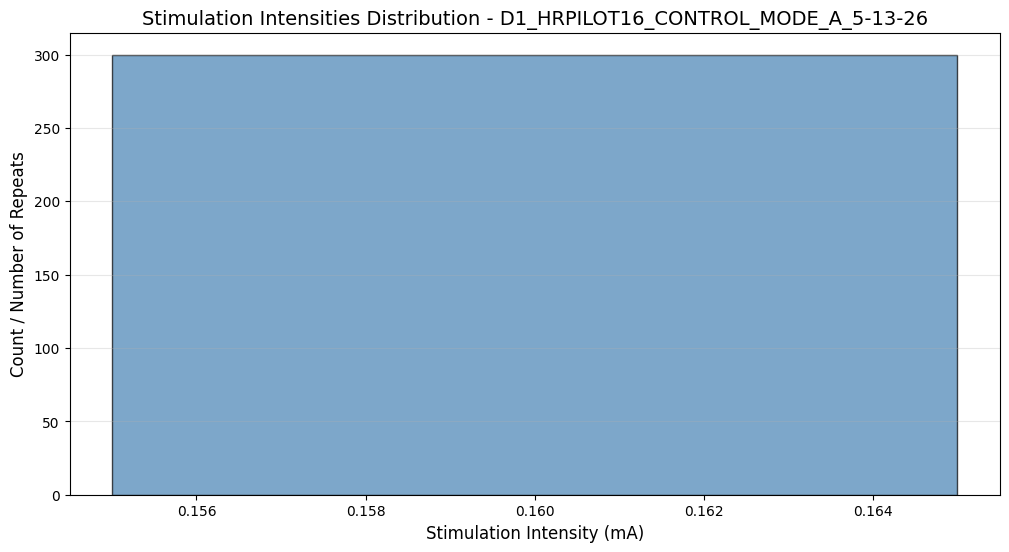

288 trials used stored bins  |  12 trials reconstructed from emg_blocks.


In [5]:
# ---- Histogram of stimulation intensities ----
plot_amplitude_distribution(hrs2_trials, hrs2_header)

# ---- "Most recent background" + "Background EMG Level" plots ----
# Mirrors the H-Reflex App recruitment-curve trial plot widgets.
# Uses stored background_bins / background_emg_mean from each trial (file_version >= 5);
# falls back to reconstructing from emg_blocks for older files.
plot_background_emg_views(hrs2_trials, hrs2_emg_blocks, monitoring_window_ms=2500,
                          sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                          bin_duration_ms=hrs1_header.bin_duration_ms)

Actual trial timeline (300 trials)
  Recording span : 5632.4 s  (1.565 h)
  Trial rate     : 191.7 trials / hour
  ITI — mean: 18837 ms  |  median: 6739 ms  |  min: 5197 ms  |  max: 339736 ms


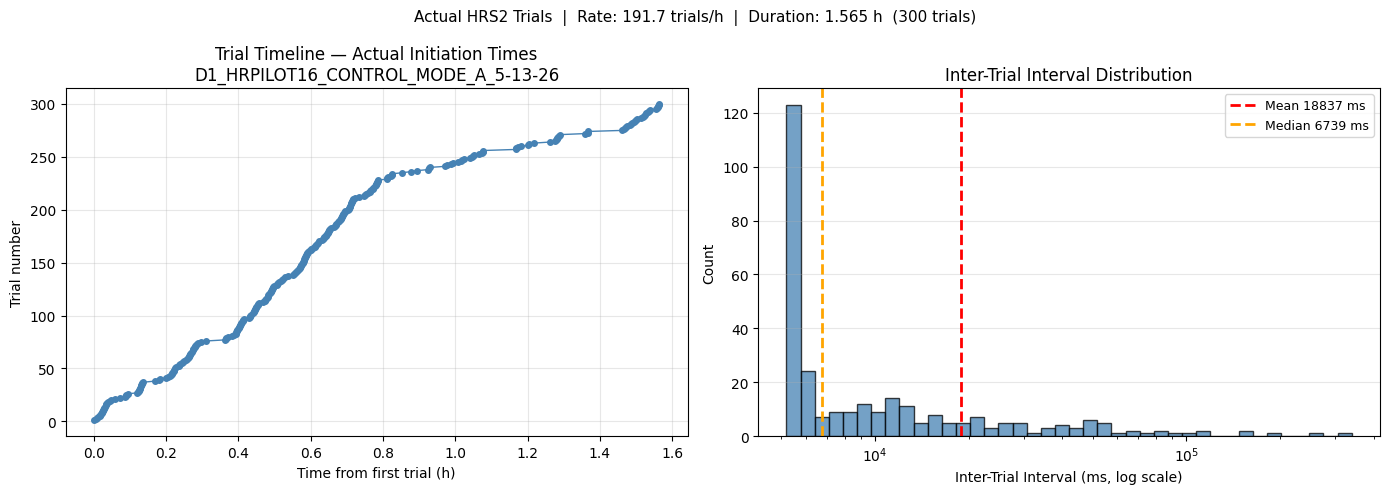

In [6]:
# ---- Actual trial timeline + ITI distribution + trial rate ----
plot_actual_trial_timeline(hrs2_trials, header=hrs2_header)

# Section 4: Post-Hoc Background EMG Analysis

Reconstruct the continuous abs-EMG signal from HRS2 EMG blocks, blank around each stimulation event, compute background statistics, extract per-trial pre-stim grand means, and run the direct background sweep.

**Steps:**
1. **4a** — Sort and stitch all HRS2 EMG blocks into one continuous signal.
2. **4b** — Build a blank mask that suppresses samples within ±[`blank_pre_ms`, `blank_post_ms`] of every stimulation event.
3. **4c** — Compute global background EMG statistics from the non-blanked signal.
4. **4d** — Extract each trial's pre-stim background grand mean and plot the distribution.
5. **4e** — Run the direct per-trial background sweep (EMG window width vs matched trials).

In [7]:
# ---- Section 4: Post-hoc background EMG analysis ----
state = analyze_global_background(
    hrs2_trials, hrs2_emg_blocks, hrs2_header,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    blank_pre_ms=5, blank_post_ms=20,
    min_valid_frac=0.7,
)

Section 4a: Reconstructing continuous signal from HRS2 EMG blocks
  Blocks stitched : 125,970
  Total samples   : 5,641,095
  Duration        : 1128.2 s  (18.8 min)
  OE sample range : 1778705721556 – 1778711362651
  Gap samples     : 821,497  (14.563% of total)

Section 4b: Building blank mask around stimulation events
Blank mask: 0 events -> 0 samples blanked (0.0000 fraction)
  Stim events mapped  : 0 of 300
  Unmapped (no onset) : 300
  Non-blanked samples : 5,641,095  (100.0%)

Section 4c: Background EMG statistics (non-blanked samples)
  n       : 5,641,095
  Mean    : 144.218 µV
  Std     : 198.444 µV
  Q1      : 7.952 µV
  Median  : 60.264 µV
  Q3      : 215.195 µV

Section 4d: Per-trial pre-stim background grand means
  Trials : 300  (failed reconstruction: 0)
  Min=78.35  Q1=216.26  Median=229.64  Q3=246.84  Max=327.86
  Recorded thresholds (mean): [163.25, 278.05] µV


# Section 4b: Virtual Trial Rate Sweep

Walks the continuous background EMG signal (with stim periods blanked) using the
same state machine as the H-Reflex app: random monitoring windows 2200–2700 ms,
50 ms bins, accepts when all bin grand means fall within the threshold window.

**Output**: virtual trial rate (trials/hour) vs EMG window half-width,
evaluated at Q1, Median, and Q3 of the background distribution.

This is the primary sweep used by the **Section 7 Optimization**.

Section 4b: Running post-hoc virtual trial rate sweep
Signal duration : 1128.2 s | Non-blanked: 100.0%
Background stats: mean=144.22  Q1=216.26  Med=229.64  Q3=246.84 µV

  Q1     (centre=216.26 µV):  ±5→217.0/hr  ±10→303.1/hr  ±20→418.0/hr  ±30→539.3/hr  ±45→698.8/hr  ±60→887.1/hr  ±75→1040.2/hr  ±100→1190.2/hr  ±125→1270.0/hr  ±150→1340.2/hr
  Median (centre=229.64 µV):  ±5→143.6/hr  ±10→172.3/hr  ±20→255.3/hr  ±30→367.0/hr  ±45→568.0/hr  ±60→711.6/hr  ±75→906.2/hr  ±100→1113.6/hr  ±125→1238.1/hr  ±150→1311.4/hr
  Q3     (centre=246.84 µV):  ±5→51.1/hr  ±10→70.2/hr  ±20→137.2/hr  ±30→197.8/hr  ±45→341.4/hr  ±60→526.5/hr  ±75→689.2/hr  ±100→963.6/hr  ±125→1167.9/hr  ±150→1257.2/hr


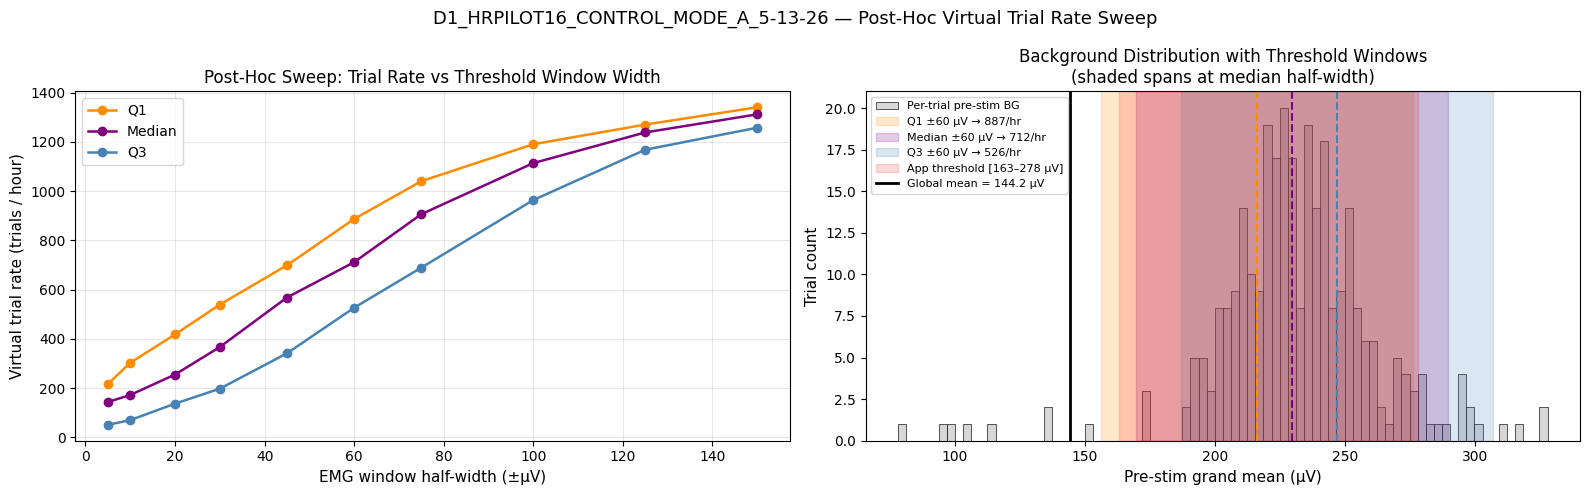


Session duration: 1128 s  (0.313 h)
Global EMG grand mean = 144.218 µV  (std=198.444, Q1=7.952, median=60.264, Q3=215.195)

    Centre   ±hw (µV)   Min (µV)   Max (µV)   Accepted    Trials/hr
-------------------------------------------------------------------
        Q1          5     211.26     221.26         68        217.0
        Q1         10     206.26     226.26         95        303.1
        Q1         20     196.26     236.26        131        418.0
        Q1         30     186.26     246.26        169        539.3
        Q1         45     171.26     261.26        219        698.8
        Q1         60     156.26     276.26        278        887.1
        Q1         75     141.26     291.26        326       1040.2
        Q1        100     116.26     316.26        373       1190.2
        Q1        125      91.26     341.26        398       1270.0
        Q1        150      66.26     366.26        420       1340.2

    Median          5     224.64     234.64         45    

In [8]:
# ---- Section 4b: Virtual trial rate sweep ----
# sweep_centres and half_widths_uv are reused by the M-H variability sweep
# in Section 6a -- keep them consistent for Section 7 optimization.
sweep_centres  = {'Q1': state['gm_q1'], 'Median': state['gm_med'], 'Q3': state['gm_q3']}
half_widths_uv = [5, 10, 20, 30, 45, 60, 75, 100, 125, 150]

sweep_results = run_threshold_sweep(
    state, sweep_centres=sweep_centres, half_widths_uv=half_widths_uv,
)
plot_threshold_sweep(sweep_results, state, hrs2_trials, hrs2_header)

In [15]:
# ---- Section 6d: Interactive bin viewer ----
view_mh_bin(
    mh_at_markers, marker_hws, hrs2_trials, mh_metrics, hrs2_header,
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    emg_blocks=hrs2_emg_blocks,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)


Pre-computing 0 ms background for each trial… done  (0/300 trials).
Pre-computing overall averages… done  (peri-stim: 300, full-window: 0 trials).


# Section 6e: H:M Ratio Summary

Box plot and histogram of H:M ratio per stimulation polarity group.
Shows distribution shape, standard deviation, CV, and 20th/80th percentiles.

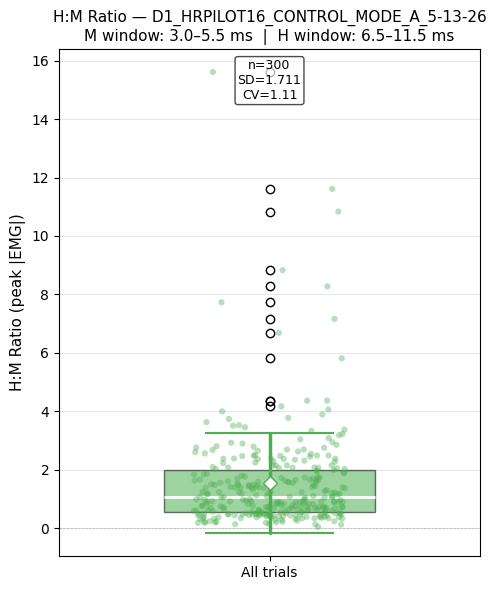

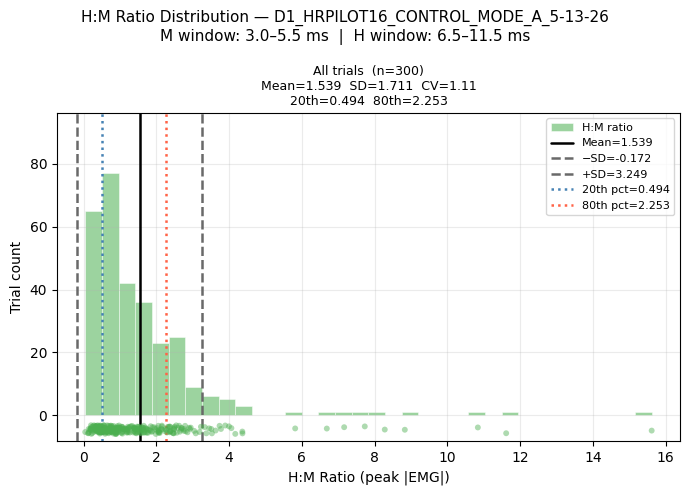

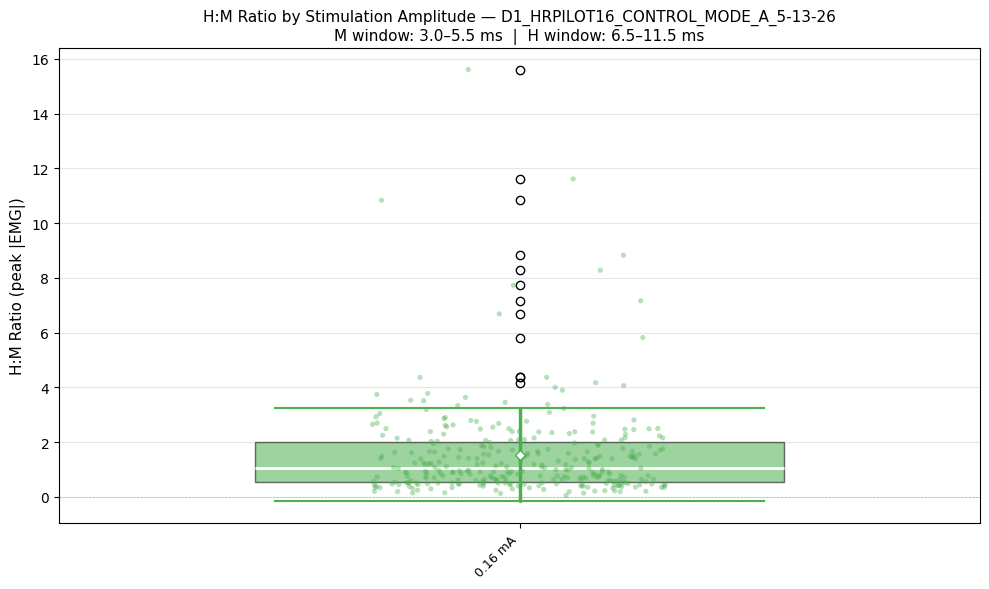

In [16]:
# ---- Stim polarity split ----
trials_by_polarity = split_trials_by_polarity(hrs2_trials)

# ---- H:M Ratio Summary: box plot + histogram ----
# Uses the same M/H windows defined in Section 6a.
plot_hm_ratio_summary(
    trials_by_polarity, hrs2_header,
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)